# Importations

In [1]:
from __future__ import annotations
import matplotlib.pyplot as plt
import time
from pathlib import Path

import numpy as np

from dataset_loader import load_labeled_image_dataset, stratified_split, _load_image_vector
from rust_bridge import MLPRust, TaskMode


# Fonctions Utilitaires et d'Affichage

In [2]:
def _print_results(
    title: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: tuple[str, ...],
) -> float:
    accuracy = float(np.mean(np.all(y_true == y_pred, axis=1)))
    confusion = _confusion_matrix(y_true, y_pred, len(class_names))

    print(f"{title}:")
    print(f"Accuracy: {accuracy:.3f}")
    print("Matrice de confusion (lignes=réel, colonnes=prédit) :")
    print("       " + " ".join(f"{name[:5]:>6}" for name in class_names))
    for row_index, row in enumerate(confusion):
        print(f"{class_names[row_index][:5]:>5} " + " ".join(f"{value:>6}" for value in row))
    return accuracy

def _confusion_matrix(y_true: np.ndarray,
                      y_pred: np.ndarray,
                      class_count: int
                      ) -> np.ndarray:
    matrix = np.zeros((class_count, class_count), dtype=np.int32)
    true_indices = np.argmax(y_true, axis=1)
    pred_indices = np.argmax(y_pred, axis=1)

    for true_index, pred_index in zip(true_indices, pred_indices):
        matrix[true_index, pred_index] += 1

    return matrix


# Chargement et Préparation du Dataset

In [3]:
etat_grayscale = True
# changer le path au besoin
chemin = r"G:\Mon Drive\Dataset projet annuel"
width = int(40 * 16/9)
height = 40

# Chargement du dataset
bundle = load_labeled_image_dataset(root=chemin, image_size=(width, height), grayscale=etat_grayscale)

# Séparation Train / Test
split_bundle = stratified_split(bundle, test_ratio=0.2, seed=42)

print("=== Dataset ===")
print(f"Chemin: {chemin}")
print(f"Classes: {', '.join(bundle.class_names)}")
print(f"Nb images train: {split_bundle.x_train.shape[0]}")
print(f"Nb images test: {split_bundle.x_test.shape[0]}")
print(f"Nb features: {split_bundle.x_train.shape[1]}")


=== Dataset ===
Chemin: G:\Mon Drive\Dataset projet annuel
Classes: FPS, METROIDVANIA, MOBA
Nb images train: 1491
Nb images test: 374
Nb features: 2840


# Entraînement du Modèle PMC (Perceptron Multi Couches)

In [6]:
start_time = time.perf_counter()
lr = 0.002
seed_modele = 42
total_steps = 1_000_000

# Initialisation du MLP
mlp = MLPRust(
    layer_sizes=[
        split_bundle.x_train.shape[1],  # Couche d'entrée
        16,                              # Couche cachée 1
        16,                              # Couche cachée 2
        16,
        len(bundle.class_names)         # Couche de sortie
    ],
    learning_rate=lr,
    task_mode=TaskMode.CLASSIFICATION,
    seed=seed_modele
)

print("Début de l'entraînement du MLP...")

# --- ENTRAÎNEMENT PAR ÉPOQUES ---
nb_echantillons_train = split_bundle.x_train.shape[0]

# Calcul du nombre d'époques
epochs = total_steps // nb_echantillons_train
steps_per_epoch = nb_echantillons_train

historique_perte_test = []

for epoch in range(epochs):
    # Entraînement sur une époque
    mlp.fit(split_bundle.x_train, split_bundle.y_train, steps=steps_per_epoch)
    
    # Prédictions sur l'ensemble de test
    mlp_predictions_test = mlp.predict(split_bundle.x_test)
    
    # Calcul du loss de test
    perte_test = float(np.mean(np.sum((mlp_predictions_test - split_bundle.y_test)**2, axis=1)))
    historique_perte_test.append(perte_test)

print("Entraînement terminé.")

# Prédictions finales sur l'ensemble de test pour la matrice de confusion
mlp_labels_predictions = mlp.predict_labels(split_bundle.x_test)

# Affichage des résultats
print("\n=== Résultats MLP ===")
accuracy_obtenue = _print_results("MLP", split_bundle.y_test, mlp_labels_predictions, bundle.class_names)
print(f"Temps total d'entraînement: {time.perf_counter() - start_time:.2f}s")

# Récupération de l'historique des pertes d'entraînement
historique_perte_train = mlp.get_loss_history()

Début de l'entraînement du MLP...
Entraînement terminé.

=== Résultats MLP ===
MLP:
Accuracy: 0.880
Matrice de confusion (lignes=réel, colonnes=prédit) :
          FPS  METRO   MOBA
  FPS     90     12      6
METRO     11    135      2
 MOBA     12      2    104
Temps total d'entraînement: 406.28s


## Affichage graphique

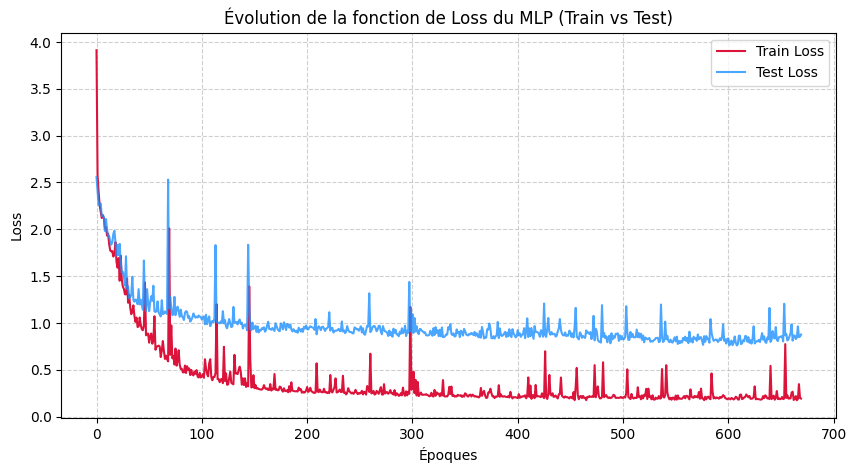

Modèle MLP sauvegardé avec succès dans : save_model\mlp\model_mlp_test.json


In [7]:
# Affichage du graphique
if len(historique_perte_train) > 0:
    plt.figure(figsize=(10, 5))
    
    # Courbe d'entraînement
    plt.plot(historique_perte_train, label="Train Loss", color="crimson")
    # Courbe de test
    plt.plot(historique_perte_test, label="Test Loss", color="dodgerblue", alpha=0.8)
    
    plt.title("Évolution de la fonction de Loss du MLP (Train vs Test)")
    plt.xlabel("Époques")
    plt.ylabel("Loss")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()
else:
    print("L'historique du loss est vide.")

# Sauvegarde du modèle entraîné avant la libération de la mémoire
mlp.class_names = bundle.class_names
dossier_sauvegarde = Path("save_model/mlp")
dossier_sauvegarde.mkdir(exist_ok=True)
chemin_modele = dossier_sauvegarde / "model_mlp_test.json"

mlp.save(str(chemin_modele), extra_hparams={"accuracy": accuracy_obtenue, "steps": total_steps})
print(f"Modèle MLP sauvegardé avec succès dans : {chemin_modele}")

# Libération de la mémoire allouée côté Rust
mlp.close()

# Chargement du Modèle et Prédiction sur une Image Unique

In [ ]:
# Rechargement du modèle MLP depuis le fichier JSON généré
nouveau_mlp = MLPRust.load("save_model/mlp/model_mlp_test.json")

# Chemin vers une image de test externe
chemin_image_test = r"C:\Users\tangu\Downloads\fps.jpg"

# Prétraitement de l'image (doit correspondre aux dimensions d'entrée)
image_vectorisee = _load_image_vector(chemin_image_test, (int(40 * 16/9), 40), grayscale=True)

# Calcul des scores et prédiction
scores_bruts = nouveau_mlp.predict(image_vectorisee)
index_predit = int(np.argmax(scores_bruts[0]))
classe_predite = nouveau_mlp.class_names[index_predit]

print(f"Fichier testé : {chemin_image_test}")
print(f"Scores bruts de sortie : {scores_bruts[0]}")
print(f"Classe prédite par le MLP : {classe_predite}")

# Toujours libérer le modèle après utilisation
nouveau_mlp.close()
